In [50]:
import pandas as pd
k = 7
df = pd.read_csv("./height-dz2.dat", header=None, names=['height'])

In [51]:
print(df.head())


    height
0  154.809
1  177.703
2  164.590
3  151.009
4  166.447


In [52]:
df.sort_values('height', inplace = True)

In [ ]:
max_height = max(df)
min_height = min(df)
df['groups'] = pd.cut(df['height'], bins = k)
print(df.head())

     height              groups
32  150.634  (150.586, 157.476]
3   151.009  (150.586, 157.476]
28  151.777  (150.586, 157.476]
0   154.809  (150.586, 157.476]
10  154.946  (150.586, 157.476]


In [32]:
df_groups_count = df['groups'].value_counts().reset_index()


In [33]:
df_groups_count = pd.DataFrame({
    'groups': df_groups_count['groups'],
    'count': df_groups_count['count'],
    'frequency': df_groups_count['count']/sum(df_groups_count['count'])
}).sort_values('groups')

In [34]:
print(df_groups_count)

               groups  count  frequency
4  (150.586, 157.476]     10       0.10
1  (157.476, 164.319]     19       0.19
2  (164.319, 171.161]     19       0.19
0  (171.161, 178.003]     28       0.28
3  (178.003, 184.845]     14       0.14
5  (184.845, 191.688]      6       0.06
6   (191.688, 198.53]      4       0.04


In [40]:
df_groups_count['middle'] = df_groups_count['groups'].apply(lambda x: (x.left + x.right)/2)

In [ ]:
print(df_groups_count)

               groups  count  frequency    middle
4  (150.586, 157.476]     10       0.10  154.0310
1  (157.476, 164.319]     19       0.19  160.8975
2  (164.319, 171.161]     19       0.19  167.7400
0  (171.161, 178.003]     28       0.28  174.5820
3  (178.003, 184.845]     14       0.14  181.4240
5  (184.845, 191.688]      6       0.06  188.2665
6   (191.688, 198.53]      4       0.04  195.1090


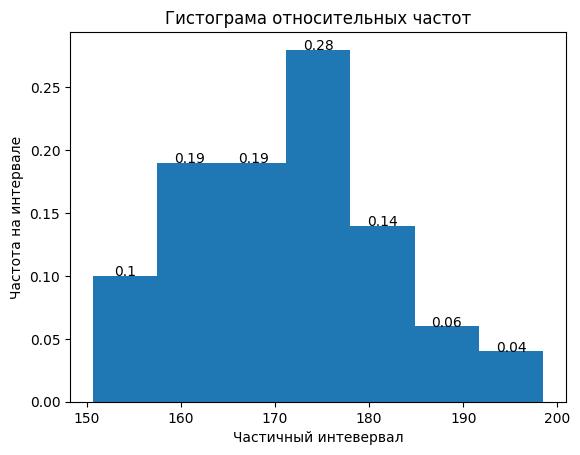

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
item = df_groups_count['groups'][0]
width = item.left - item.right
bars = ax.bar(df_groups_count['middle'],
              df_groups_count['frequency'],
              width = width,
              align = 'center')

ax.set_xlabel('Частичный интевервал')
ax.set_ylabel('Частота на интервале')
ax.set_title('Гистограма относительных частот')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, height, str(float(height)), ha = 'center')


In [48]:
print('Несмещенное выборочное среднее:')
print(round(df['height'].mean(), 3))

Несмещенное выборочное среднее:
171.383


In [49]:
print('Несмещенная выборочная дисперсия:')
print(round(df['height'].var(), 3))

Несмещенная выборочная дисперсия:
113.655
